# DriveValue AI: Feature Engineering & Data Preprocessing
## Capstone Project
**Author:** Jacqualine Makgolana

## Purpose

The purpose of this notebook is to prepare the cleaned dataset for machine learning.

This includes handling missing values, engineering useful features, encoding categorical variables, scaling numerical features where appropriate, and splitting the data into training and testing datasets. The resulting dataset will be used to train and evaluate regression models that predict used car asking prices.

## CRISP-DM Phase

This notebook focuses on the **Data Preparation** phase of the CRISP-DM methodology.

The objective is to transform the cleaned dataset into a machine learning-ready format by handling missing values, engineering features, encoding categorical variables, and creating separate training and testing datasets for model development.

In [59]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

In [60]:
df = pd.read_csv("../Data/processed/used_cars_cleaned.csv")

print(df.shape)

df.head()

(14988, 11)


,Brand,model,Year,Age,kmDriven,Transmission,Owner,FuelType,PostedDate,AdditionInfo,AskPrice
0,NaN,NaN,2001.0,23.0,98000.0,NaN,NaN,Unknown,Nov-24,"Honda City v teck in mint condition, valid gen...",195000
1,Toyota,NaN,NaN,15.0,190000.0,Manual,NaN,Diesel,Jul-24,"Toyota Innova 2.5 G (Diesel) 7 Seater, 2009, D...",375000
2,Volkswagen,NaN,2010.0,NaN,NaN,Manual,first,NaN,Nov-24,"Volkswagen Vento 2010-2013 Diesel Breeze, 2010...",184999
3,NaN,Swift,2017.0,7.0,NaN,Manual,second,Unknown,NaN,Maruti Suzuki Swift 2017 Diesel Good Condition,565000
4,Maruti Suzuki,NaN,2019.0,5.0,NaN,Automatic,NaN,Unknown,Nov-24,"Maruti Suzuki Baleno Alpha CVT, 2019, Petrol",685000


## Question 1

### Which features contain missing values that require preprocessing?

Missing values can negatively affect machine learning algorithms by reducing predictive performance or preventing models from training successfully. Identifying incomplete variables allows appropriate preprocessing strategies to be selected before model development.


In [61]:
df.isnull().sum().sort_values(ascending=False)

Owner           5329
model           5233
Year            3300
kmDriven        3148
PostedDate      3121
Age             2993
Transmission    2970
Brand           2641
FuelType        2629
AdditionInfo       0
AskPrice           0
dtype: int64

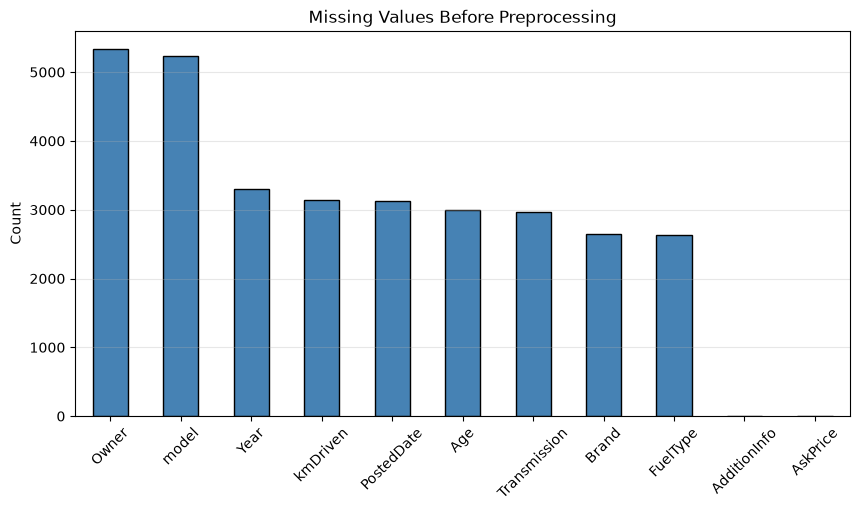

In [62]:
missing = df.isnull().sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

missing.plot(kind="bar", color="steelblue", edgecolor="black")

plt.title("Missing Values Before Preprocessing")

plt.ylabel("Count")

plt.xticks(rotation=45)

plt.grid(axis="y", alpha=0.3)

plt.show()

## Question 2

### How should missing values be handled?

Missing values must be addressed before training machine learning models because many algorithms cannot process incomplete observations. Appropriate imputation techniques help preserve valuable information while minimizing the impact of missing data on model performance.




In [63]:
df["Brand"] = df["Brand"].fillna("Unknown")
df["model"] = df["model"].fillna("Unknown")
df["Owner"] = df["Owner"].fillna("Unknown")
df["FuelType"] = df["FuelType"].fillna("Unknown")
df["Transmission"] = df["Transmission"].fillna("Unknown")
df["PostedDate"] = df["PostedDate"].fillna("Unknown")

In [64]:
df["Year"] = df["Year"].fillna(df["Year"].median())
df["Age"] = df["Age"].fillna(df["Age"].median())
df["kmDriven"] = df["kmDriven"].fillna(df["kmDriven"].median())

In [65]:
df.isnull().sum()

Brand           0
model           0
Year            0
Age             0
kmDriven        0
Transmission    0
Owner           0
FuelType        0
PostedDate      0
AdditionInfo    0
AskPrice        0
dtype: int64

## Interpretation ##

Missing values were successfully handled using appropriate strategies based on each variable type. Numerical variables (Year, Age and kmDriven) were imputed using the median to reduce the influence of outliers, while categorical variables were filled with "Unknown" to preserve missing information without removing observations. After preprocessing, no missing values remained in the dataset.

## Question 3

### Which features should be retained for machine learning?

Not every variable contributes equally to predictive performance. Removing irrelevant or unstructured features simplifies the dataset and reduces unnecessary model complexity.


In [66]:
df = df.drop(columns=["AdditionInfo"])

In [67]:
X = df.drop("AskPrice", axis=1)

y = df["AskPrice"]

# Feature Engineering #

Machine learning algorithms require numerical input features. Therefore, categorical variables such as Brand, FuelType, Transmission, Owner, Model and PostedDate were converted into numerical indicators using One-Hot Encoding.

The AdditionInfo column was removed because it contains unstructured text that will not be used in the baseline regression models.

## Question 4

### How can categorical variables be converted into numerical features?

Most machine learning algorithms require numerical input variables. One-Hot Encoding transforms categorical variables into binary indicator variables while preserving the information contained within each category.


In [68]:
X = pd.get_dummies(
    X,
    drop_first=True
)

X.head()

,Year,Age,kmDriven,Brand_Audi,Brand_BMW,Brand_Bajaj,Brand_Bentley,Brand_Chevrolet,Brand_Citroen,Brand_Datsun,...,PostedDate_Dec-24,PostedDate_Jan-24,PostedDate_Jul-24,PostedDate_Jun-24,PostedDate_Mar-24,PostedDate_May-24,PostedDate_Nov-24,PostedDate_Oct-24,PostedDate_Sep-24,PostedDate_Unknown
0,2001.0,23.0,98000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,2017.0,15.0,190000.0,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,2010.0,7.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,2017.0,7.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2019.0,5.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


In [69]:
print(X.shape)

X.head()

(14988, 466)


,Year,Age,kmDriven,Brand_Audi,Brand_BMW,Brand_Bajaj,Brand_Bentley,Brand_Chevrolet,Brand_Citroen,Brand_Datsun,...,PostedDate_Dec-24,PostedDate_Jan-24,PostedDate_Jul-24,PostedDate_Jun-24,PostedDate_Mar-24,PostedDate_May-24,PostedDate_Nov-24,PostedDate_Oct-24,PostedDate_Sep-24,PostedDate_Unknown
0,2001.0,23.0,98000.0,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,2017.0,15.0,190000.0,False,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2,2010.0,7.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,2017.0,7.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,2019.0,5.0,65868.5,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False


### Interpretation

Following One-Hot Encoding, the number of predictor variables increased from 10 original features to 466 engineered features.

This increase is expected because each categorical category is converted into its own binary indicator variable, enabling machine learning algorithms to process categorical information effectively.

## Question 5

### How should the dataset be divided for model development?

Splitting the dataset into training and testing subsets allows model performance to be evaluated on unseen data, reducing the risk of overfitting and providing a realistic estimate of predictive accuracy.

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (11990, 466)
Testing : (2998, 466)


# Interpretation #

The dataset was divided into training (80%) and testing (20%) subsets using a fixed random state to ensure reproducibility. The training dataset will be used to develop machine learning models, while the testing dataset will provide an unbiased evaluation of model performance on unseen data.

In [71]:
X_train.to_csv("../Data/processed/X_train.csv", index=False)

X_test.to_csv("../Data/processed/X_test.csv", index=False)

y_train.to_csv("../Data/processed/y_train.csv", index=False)

y_test.to_csv("../Data/processed/y_test.csv", index=False)

print("Datasets saved successfully!")

Datasets saved successfully!


## Question 6

### Is the processed dataset ready for machine learning?

Before model development begins, it is important to verify that the processed datasets contain no missing values and have been prepared correctly.

In [72]:
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

print("\nMissing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_test :", X_test.isnull().sum().sum())

X_train shape: (11990, 466)
X_test shape : (2998, 466)
y_train shape: (11990,)
y_test shape : (2998,)

Missing values in X_train: 0
Missing values in X_test : 0


# interpretation #

The preprocessing stage was successfully completed. Missing values were handled, categorical variables were encoded into numerical features, and the dataset was divided into training and testing subsets. The resulting datasets contain no missing values and are ready for regression model development.

## Summary

# The cleaned dataset was successfully prepared for machine learning. 

The preprocessing process included:

- Handling missing values
- Removing unnecessary features
- Encoding categorical variables
- Separating predictor variables from the target variable
- Splitting the dataset into training and testing datasets

The processed datasets are now ready for model development and evaluation in the next notebook.